# Phase 8 Final Evaluation: EXP-11-RunB2 ResNet-50

This notebook evaluates the optimized ResNet-50 classifier on the strictly untouched **Test Set**, and then runs the complete Two-Stage pipeline End-to-End.

In [2]:
# Mount Google Drive
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/sem_defect_project'
os.chdir(PROJECT_ROOT)
print(f"Current working directory: {os.getcwd()}")


Mounted at /content/drive
Current working directory: /content/drive/MyDrive/sem_defect_project


In [3]:
# Install dependencies
!pip install ultralytics pandas pyyaml scikit-learn torch torchvision seaborn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.1 MB/s eta 0:00:00


## PART A: Standalone ResNet Classifier Evaluation (Test Set)
Evaluating the EXP-11-RunB2 model on the test split of `classifier_crops.zip`.

Extracting classifier crops...
Extraction complete.
Loading weights from /content/drive/MyDrive/sem_defect_project/runs/classify/EXP-11-RunB2/best.pt...

=== PART A: RESNET CLASSIFIER TEST SET RESULTS ===
Accuracy:    0.8607
Macro F1:    0.8488
Weighted F1: 0.8603

Classification Report:
                    precision    recall  f1-score   support

Inclusion-Particle       0.87      0.87      0.87        38
          Porosity       0.87      0.89      0.88        61
 Tear-Delamination       0.82      0.78      0.80        23

          accuracy                           0.86       122
         macro avg       0.85      0.85      0.85       122
      weighted avg       0.86      0.86      0.86       122



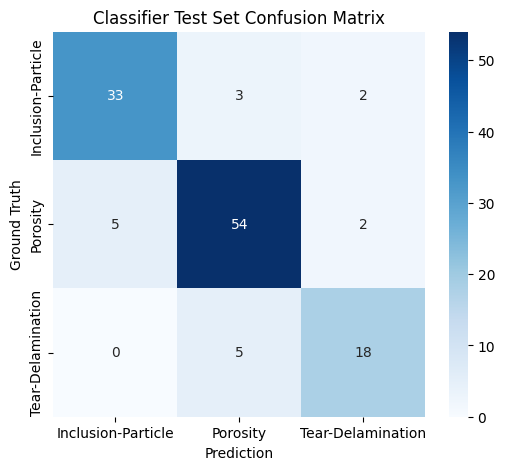

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Extract dataset if not already done
ZIP_PATH = os.path.join(PROJECT_ROOT, 'classifier_crops.zip')
DATASET_ROOT = '/content/classifier_crops'

if not os.path.exists(DATASET_ROOT):
    print("Extracting classifier crops...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content')
    print("Extraction complete.")

# Setup Dataloader for Test Set
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = datasets.ImageFolder(os.path.join(DATASET_ROOT, 'test'), transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
class_names = test_ds.classes

# Load EXP-11-RunB2
model_path = os.path.join(PROJECT_ROOT, 'runs/classify/EXP-11-RunB2/best.pt')
print(f"Loading weights from {model_path}...")

model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, 3))
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# Evaluate
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
report = classification_report(all_labels, all_preds, target_names=class_names)

print("\n=== PART A: RESNET CLASSIFIER TEST SET RESULTS ===")
print(f"Accuracy:    {acc:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("\nClassification Report:")
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Classifier Test Set Confusion Matrix')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()


## PART B: End-to-End Evaluation (Two-Stage Pipeline)
Running the full pipeline using the embedded classes.

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Install dependencies
!pip install ultralytics

In [7]:
# Set up paths
import os
import sys

PROJECT_ROOT = '/content/drive/MyDrive/sem_defect_project'
os.chdir(PROJECT_ROOT)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/sem_defect_project


In [8]:
# Extract the true 3-class test set to Colab's high-speed local storage
import zipfile
import shutil
import glob

zip_path = 'test_3class.zip'
local_extract_dir = '/content/test_3class'

if os.path.exists(zip_path):
    print(f"Extracting {zip_path} to {local_extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_dir)
    print("Extracted successfully.")
elif os.path.exists('/content/test_3class.zip'):
    print(f"Extracting /content/test_3class.zip to {local_extract_dir}...")
    with zipfile.ZipFile('/content/test_3class.zip', 'r') as zip_ref:
        zip_ref.extractall(local_extract_dir)
    print("Extracted successfully.")
else:
    print("test_3class.zip not found! Please upload it.")

# Fix Windows backslash issue if extracted on Linux
import os
import shutil

for root, dirs, files in os.walk(local_extract_dir):
    for file in files:
        if '\\' in file:
            # The zip extracted files with backslashes in their names instead of folders
            new_path = file.replace('\\', '/')
            full_new_path = os.path.join(local_extract_dir, new_path)
            
            # Create directories
            os.makedirs(os.path.dirname(full_new_path), exist_ok=True)
            
            # Move file
            shutil.move(os.path.join(root, file), full_new_path)
print("Zip extraction paths normalized.")


Extracting test_3class.zip to /content/test_3class...
Extracted successfully.
Zip extraction paths normalized.


## 1. Define Two-Stage Pipeline (Inference Logic)

In [9]:
import os
import torch
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import numpy as np

class TwoStagePipeline:
    def __init__(self, yolo_weights_path, resnet_weights_path, device=None, conf_thresh=0.25, padding_factor=0.10):
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.conf_thresh = conf_thresh
        self.padding_factor = padding_factor
        
        # Load YOLO
        self.detector = YOLO(yolo_weights_path)
        self.detector.to(self.device)
        
        # Load ResNet-50
        self.classifier = models.resnet50(weights=None)
        num_ftrs = self.classifier.fc.in_features
        self.classifier.fc = torch.nn.Sequential(
            torch.nn.Dropout(0.5),
            torch.nn.Linear(num_ftrs, 3)
        )
        self.classifier.load_state_dict(torch.load(resnet_weights_path, map_location=self.device))
        self.classifier.to(self.device)
        self.classifier.eval()
        
        self.class_names = ['Inclusion-Particle', 'Porosity', 'Tear-Delamination']
        
        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def predict(self, image_path):
        # 1. Detection
        results = self.detector.predict(image_path, conf=self.conf_thresh, verbose=False)
        boxes = results[0].boxes
        
        original_img = Image.open(image_path).convert("RGB")
        img_width, img_height = original_img.size
        
        predictions = []
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            yolo_conf = float(box.conf[0].cpu().numpy())
            
            # Apply 10% contextual padding
            w = x2 - x1
            h = y2 - y1
            pad_x = w * self.padding_factor
            pad_y = h * self.padding_factor
            
            crop_x1 = max(0, x1 - pad_x)
            crop_y1 = max(0, y1 - pad_y)
            crop_x2 = min(img_width, x2 + pad_x)
            crop_y2 = min(img_height, y2 + pad_y)
            
            # 2. Crop
            crop_img = original_img.crop((crop_x1, crop_y1, crop_x2, crop_y2))
            
            # 3. Classification
            input_tensor = self.preprocess(crop_img).unsqueeze(0).to(self.device)
            with torch.no_grad():
                outputs = self.classifier(input_tensor)
                probs = torch.nn.functional.softmax(outputs, dim=1)
                resnet_conf, preds = torch.max(probs, 1)
                
            pred_class = self.class_names[preds.item()]
            resnet_conf = float(resnet_conf.item())
            
            predictions.append({
                'bbox': [x1, y1, x2, y2],
                'yolo_conf': yolo_conf,
                'pred_class': pred_class,
                'resnet_conf': resnet_conf
            })
            
        return predictions, original_img

    def draw_predictions(self, image, predictions, output_path=None):
        draw = ImageDraw.Draw(image)
        try:
            font = ImageFont.truetype("LiberationSans-Regular.ttf", 16)
        except IOError:
            font = ImageFont.load_default()
            
        colors = {
            'Inclusion-Particle': 'red',
            'Porosity': 'blue',
            'Tear-Delamination': 'green'
        }
        
        for p in predictions:
            x1, y1, x2, y2 = p['bbox']
            cls_name = p['pred_class']
            y_conf = p['yolo_conf']
            r_conf = p['resnet_conf']
            
            color = colors.get(cls_name, 'yellow')
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            
            label = f"{cls_name}\nYOLO: {y_conf:.2f}\nResNet: {r_conf:.2f}"
            
            # Text background
            text_bbox = draw.textbbox((x1, y1), label, font=font)
            draw.rectangle(text_bbox, fill="black")
            draw.text((x1, y1), label, fill="white", font=font)
            
        if output_path:
            image.save(output_path)
            
        return image


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 2. Define Evaluation Logic

In [10]:
import glob
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_iou(box1, box2):
    # box format: [x1, y1, x2, y2]
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = float(box1_area + box2_area - intersection_area)

    return intersection_area / union_area if union_area > 0 else 0.0

def load_ground_truth(label_path, img_width, img_height, class_names):
    gt_boxes = []
    if not os.path.exists(label_path):
        return gt_boxes
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            class_id = int(parts[0])
            x_center = float(parts[1]) * img_width
            y_center = float(parts[2]) * img_height
            width = float(parts[3]) * img_width
            height = float(parts[4]) * img_height
            
            x1 = x_center - (width / 2)
            y1 = y_center - (height / 2)
            x2 = x_center + (width / 2)
            y2 = y_center + (height / 2)
            
            gt_boxes.append({
                'bbox': [x1, y1, x2, y2],
                'class': class_names[class_id]
            })
            
    return gt_boxes

def evaluate_e2e(test_img_dir, test_label_dir, output_dir, pipeline, iou_thresh=0.50):
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'correct'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'detection_missed'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'false_positive'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'classification_wrong'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'low_confidence'), exist_ok=True)

    image_paths = glob.glob(os.path.join(test_img_dir, '*.jpg'))
    
    if not image_paths:
        print(f"Error: No images found in {test_img_dir}!")
        return
        
    all_true_classes = []
    all_pred_classes = []
    
    total_gt = 0
    total_preds = 0
    true_positives = 0
    
    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        label_name = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(test_label_dir, label_name)
        
        # Run inference
        preds, img = pipeline.predict(img_path)
        img_width, img_height = img.size
        
        gt_boxes = load_ground_truth(label_path, img_width, img_height, pipeline.class_names)
        
        total_gt += len(gt_boxes)
        total_preds += len(preds)
        
        matched_gt_indices = set()
        
        for p in preds:
            best_iou = 0
            best_gt_idx = -1
            
            for i, gt in enumerate(gt_boxes):
                if i in matched_gt_indices:
                    continue
                iou = calculate_iou(p['bbox'], gt['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i
                    
            if best_iou >= iou_thresh:
                matched_gt_indices.add(best_gt_idx)
                gt_class = gt_boxes[best_gt_idx]['class']
                pred_class = p['pred_class']
                
                all_true_classes.append(gt_class)
                all_pred_classes.append(pred_class)
                
                if gt_class == pred_class:
                    true_positives += 1
                    
                    if p['yolo_conf'] < 0.5 or p['resnet_conf'] < 0.5:
                        out_path = os.path.join(output_dir, 'low_confidence', img_name)
                    else:
                        out_path = os.path.join(output_dir, 'correct', img_name)
                else:
                    out_path = os.path.join(output_dir, 'classification_wrong', img_name)
                
                pipeline.draw_predictions(img.copy(), [p], out_path)
            else:
                out_path = os.path.join(output_dir, 'false_positive', img_name)
                pipeline.draw_predictions(img.copy(), [p], out_path)
                
        # Find missed detections
        for i, gt in enumerate(gt_boxes):
            if i not in matched_gt_indices:
                out_path = os.path.join(output_dir, 'detection_missed', img_name)
                pipeline.draw_predictions(img.copy(), [], out_path)
                
    # Calculate end-to-end metrics
    e2e_precision = true_positives / total_preds if total_preds > 0 else 0
    e2e_recall = true_positives / total_gt if total_gt > 0 else 0
    e2e_f1 = 2 * (e2e_precision * e2e_recall) / (e2e_precision + e2e_recall) if (e2e_precision + e2e_recall) > 0 else 0
    
    clf_report = classification_report(all_true_classes, all_pred_classes, output_dict=True, zero_division=0)
    
    metrics = {
        'total_images': len(image_paths),
        'total_ground_truth': total_gt,
        'total_predictions': total_preds,
        'true_positives_e2e': true_positives,
        'e2e_precision': e2e_precision,
        'e2e_recall': e2e_recall,
        'e2e_f1': e2e_f1,
        'classification_report_on_matched': clf_report
    }
    
    with open(os.path.join(output_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=4)
        
    print("End-to-End Metrics:")
    print(f"Precision: {e2e_precision:.4f}")
    print(f"Recall: {e2e_recall:.4f}")
    print(f"F1-Score: {e2e_f1:.4f}")
    print("\nClassification Report (on matched boxes):")
    print(classification_report(all_true_classes, all_pred_classes, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(all_true_classes, all_pred_classes, labels=pipeline.class_names)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.class_names, yticklabels=pipeline.class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('End-to-End Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))


## 3. Execute End-to-End Run

Found images directory: /content/test_3class/test/images
Number of images: 30
Initializing Two-Stage Pipeline...
Starting Evaluation on /content/test_3class/test/images...
End-to-End Metrics:
Precision: 0.5798
Recall: 0.5656
F1-Score: 0.5726

Classification Report (on matched boxes):
                    precision    recall  f1-score   support

Inclusion-Particle       0.96      0.83      0.89        30
          Porosity       0.86      0.89      0.87        35
 Tear-Delamination       0.72      0.87      0.79        15

          accuracy                           0.86        80
         macro avg       0.85      0.86      0.85        80
      weighted avg       0.87      0.86      0.86        80

Evaluation Complete. Results saved to /content/drive/MyDrive/sem_defect_project/runs/end_to_end_EXP11_RunB2/


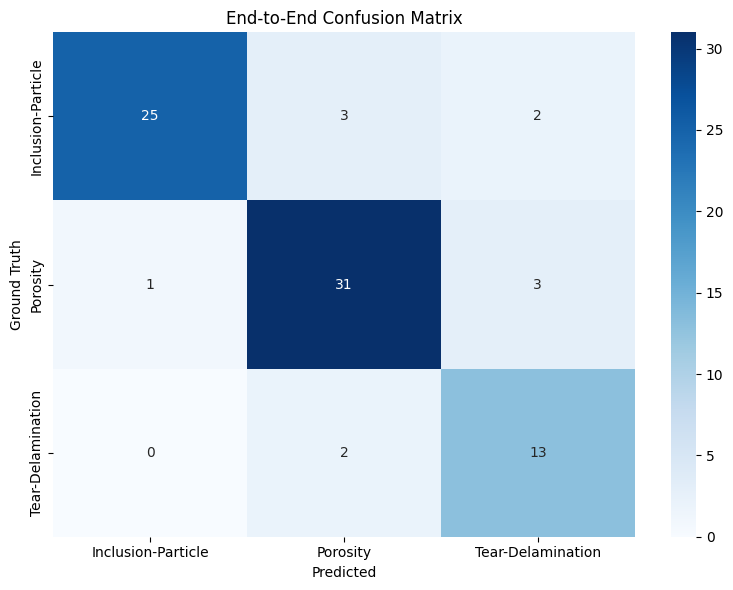

In [11]:
# Check if the extracted directory exists
import os
import glob

# The exact absolute paths for the test data
test_img_dir = '/content/test_3class/test/images'
test_label_dir = '/content/test_3class/test/labels'
output_dir = '/content/drive/MyDrive/sem_defect_project/runs/end_to_end_EXP11_RunB2'

if not os.path.exists(test_img_dir):
    print(f"Directory {test_img_dir} does not exist! Please ensure you run the unzip cell above.")
else:
    print(f"Found images directory: {test_img_dir}")
    print(f"Number of images: {len(glob.glob(os.path.join(test_img_dir, '*.jpg')))}")

# HARDCODED TO THE OPTIMAL SETTINGS
yolo_conf_thresh = 0.15
iou_thresh = 0.50
padding_factor = 0.10

# Paths for models 
yolo_weights = '/content/drive/MyDrive/sem_defect_project/runs/detect/runs/detect/EXP-10-YOLOv12m-640-200/weights/best.pt'
resnet_weights = '/content/drive/MyDrive/sem_defect_project/runs/classify/EXP-11-RunB2/best.pt'

if not os.path.exists(yolo_weights):
    print(f"Error: YOLO weights not found at {yolo_weights}")
if not os.path.exists(resnet_weights):
    print(f"Error: ResNet weights not found at {resnet_weights}")

print("Initializing Two-Stage Pipeline...")
pipeline = TwoStagePipeline(
    yolo_weights_path=yolo_weights,
    resnet_weights_path=resnet_weights,
    conf_thresh=yolo_conf_thresh,
    padding_factor=padding_factor
)

print(f"Starting Evaluation on {test_img_dir}...")
evaluate_e2e(test_img_dir, test_label_dir, output_dir, pipeline, iou_thresh=iou_thresh)

print(f"Evaluation Complete. Results saved to {output_dir}/")
